In [1]:
import os

# Set OMP_NUM_THREADS to 4
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"]="1"

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy
import geopandas as gpd
from shapely.geometry import Point
import utils
import scipy.stats as stats

In [3]:
import scipy.signal as signal
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [ ]:
yearb=1941
yeare=2025

ifile='/AnnualMaximumDailyTmax.era5.1941.2025.nc4'

dso = xr.open_dataset(ifile)
dso = dso.drop_vars('TXx_day')
dso['time'] = np.arange(1941,2025+1,1)

dso = dso.sel(time=slice(f'{yearb-1}-01-01',f'{yeare}-02-01'))
dso = dso.sortby('lat')

units = 'K'

# K to Farenheit
dso['TXx'] = (dso['TXx'] - 273.15) * 9/5 + 32 
units = f'$\degree$ F'

In [ ]:
dsm = xr.open_dataset('/lsmask.nc')
dsm = dsm.sortby('lat')
dsm = dsm.isel(time=0, drop=True)
dsm = dsm.sel(lon=dso['lon'],lat=dso['lat'])

dso['TXx'] = dso['TXx'].where(dsm['lsmask']>=0.55)

In [8]:
lon_min = 190
lon_max = 310 
lat_min =  19
lat_max =  75 
ds = dso.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
Tlon = ds.lon.data
Tlat = ds.lat.data

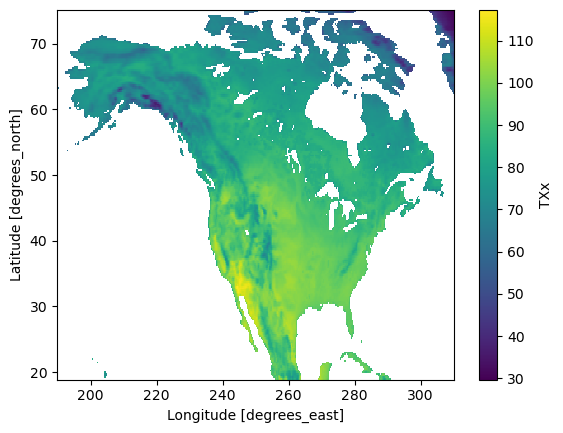

In [9]:
ds['TXx'].mean('time').plot()

In [10]:
import pymannkendall as mk

# Compute Durbin-Watson & Augmented Dickey-Fuller (ADF)  test 

In [11]:
import pymannkendall as mk
import numpy as np

# Sample data
data = np.random.rand(100) + np.linspace(0, 1, 100) 
result = mk.original_test(data)
result.p

0.0

In [12]:
dw = xr.zeros_like(ds['TXx'].mean('time'))*np.nan
adf = xr.zeros_like(ds['TXx'].mean('time'))*np.nan
mkp = xr.zeros_like(ds['TXx'].mean('time'))*np.nan
mkt = xr.zeros_like(ds['TXx'].mean('time'))*np.nan

mask=xr.where(np.isnan(ds['TXx'].mean('time'))==False,1,0)

idlat,idlon=np.where(mask==1)

# 1. Prepare your data (Example: y depends on x)
x = ds['time'].data 

for ij in range(0,len(idlon)):
  jj=idlat[ij]
  ii=idlon[ij]
  ilon=Tlon[ii]
  ilat=Tlat[jj]

  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat)


  y = dsij['TXx'].data

  # 2. Fit a regression model
  x = sm.add_constant(x) # Add an intercept
  model = sm.OLS(y, x).fit()

  # 3. Perform Durbin-Watson test on the residuals
  dw_statistic = durbin_watson(model.resid)
  result_adf = adfuller(y)
  result_mk = mk.original_test(y)

  dw.loc[{'lat':ilat,'lon':ilon}] = dw_statistic
  adf.loc[{'lat':ilat,'lon':ilon}] = result_adf[1]
  mkp.loc[{'lat':ilat,'lon':ilon}] = result_mk.p
  mkt.loc[{'lat':ilat,'lon':ilon}] = result_mk.Tau

Text(0.5, 1.0, 'Durbin-Watson statistic')

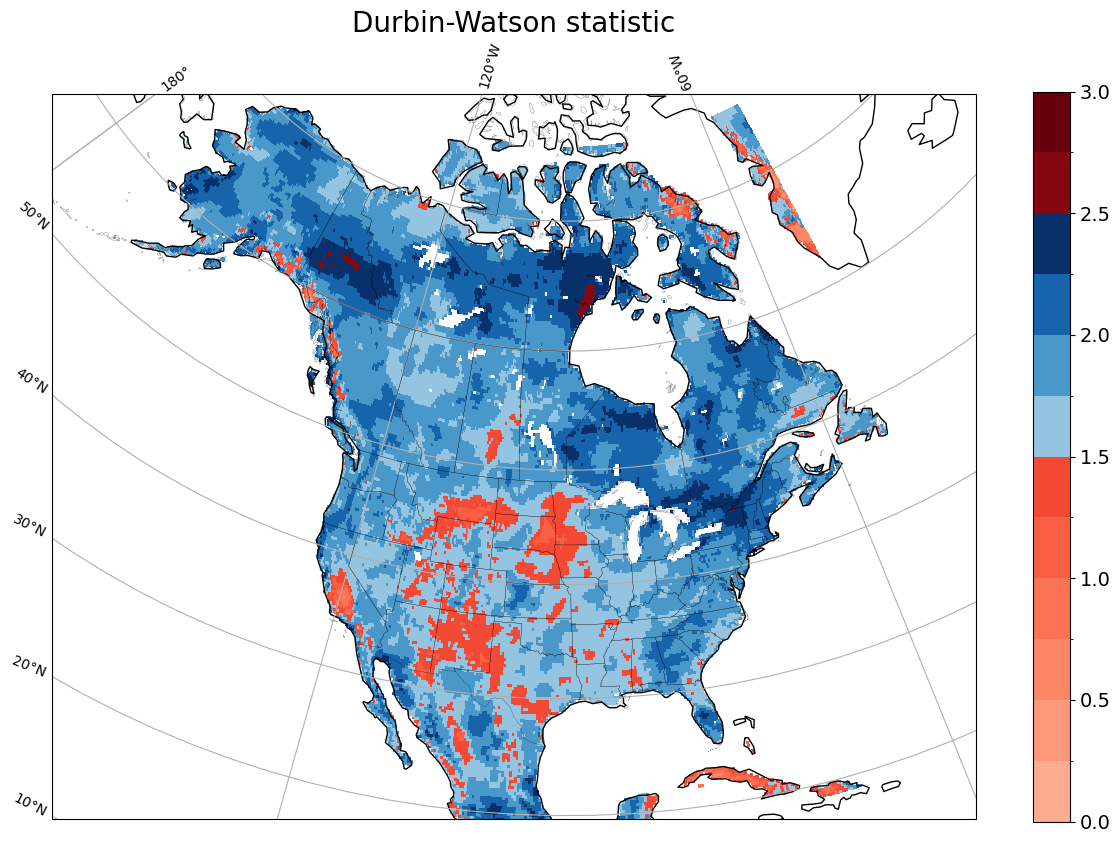

In [59]:
from matplotlib import colors
clevs = np.arange(0,3.25,0.25)
cmap_r=plt.get_cmap('Reds',len(clevs)+5)
cmap_b=plt.get_cmap('Blues',4+2)
ccolors = [cmap_r(i) for i in range(5,cmap_r.N)]
ccolors[np.where(clevs==1.5)[0].item():np.where(clevs==2.5)[0].item()+1]=[cmap_b(i) for i in range(2,cmap_b.N)]
cmap= colors.LinearSegmentedColormap.from_list('Custom cmap',\
                ccolors, len(ccolors))
proj=ccrs.LambertConformal(265,25)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.95)

clevs = np.arange(0,3.25,0.25)
cc=dw.plot.pcolormesh(ax=ax,cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),\
                        add_colorbar=False)
ax.set_extent([-140+360, -60, 15, 75], ccrs.Geodetic())
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
cbar=fig.colorbar(cc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)  
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels
plt.title(f'Durbin-Watson statistic',fontsize=20)

The Durbin-Watson statistic is a test for autocorrelation in the residuals of a regression analysis. The Durbin-Watson statistic will always have a value ranging between 0 and 4. A value of 2.0 indicates there is no autocorrelation detected in the sample. Values from 0 to less than 2 point to positive autocorrelation, and values from 2 to 4 mean negative autocorrelation. Typically, the Durbin-Watson statistic values that are in the range of 1.5 to 2.5 are considered normal.

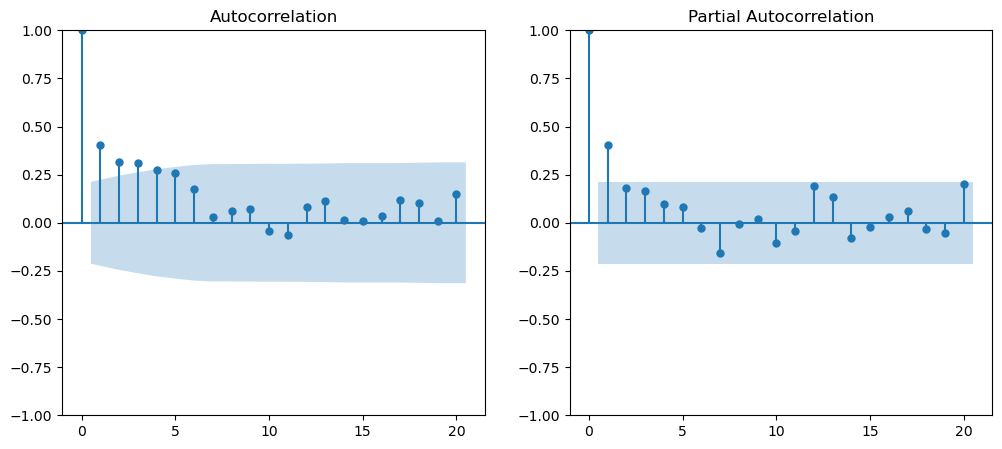

In [63]:
dsij=ds.sel(lon=255.5,lat=35.5)
x = dsij['time'].data
y = dsij['TXx'].data
#sm.graphics.tsa.plot_acf(y)
#plt.show()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,5))
sm.graphics.tsa.plot_acf(y,ax=ax[0])
sm.graphics.tsa.plot_pacf(y,ax=ax[1])
plt.show()

In [ ]:
## Build colorbar
from matplotlib import cm
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
clevs_pv=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

Text(0.5, 1.0, 'ADF pvalue')

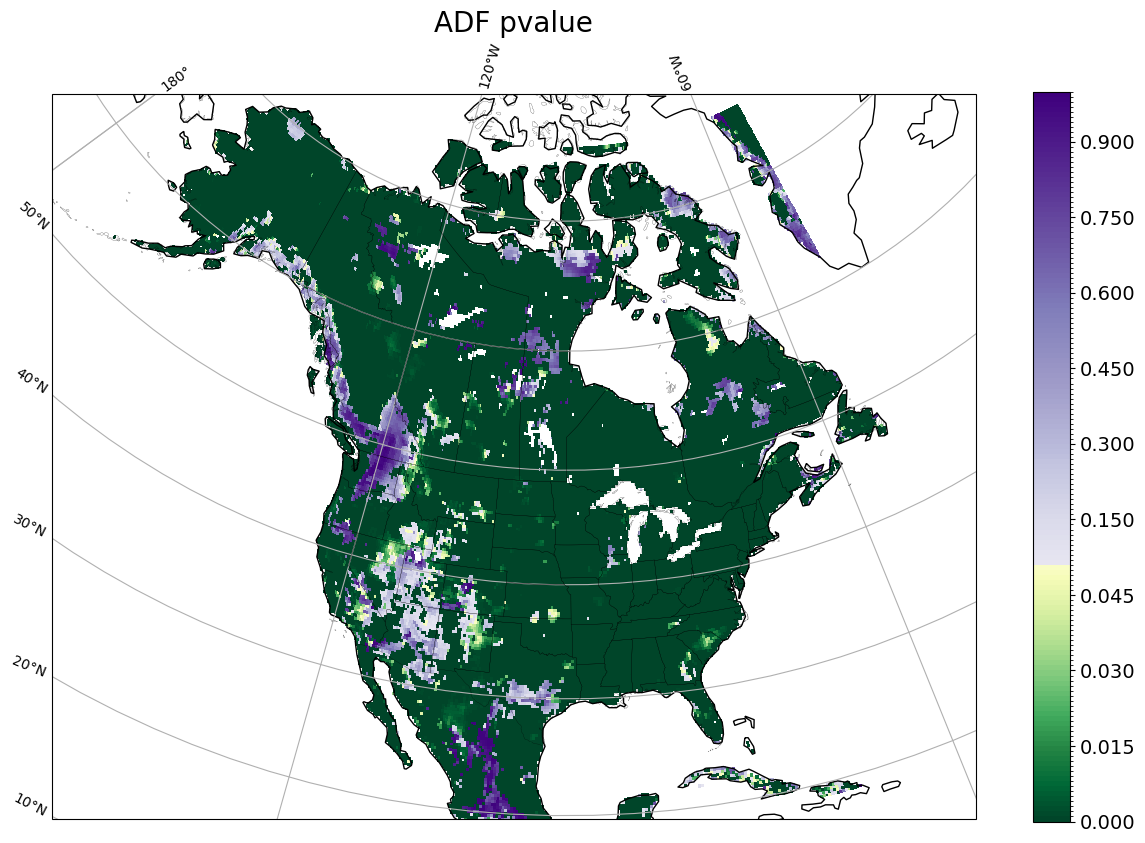

In [82]:
proj=ccrs.LambertConformal(265,25)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.95)

clevs = np.arange(0,3.25,0.25)
cc=adf.plot.pcolormesh(ax=ax,cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(), add_colorbar=False)
ax.set_extent([-140+360, -60, 15, 75], ccrs.Geodetic())
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
cbar=fig.colorbar(cc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)  
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels
plt.title(f'ADF pvalue',fontsize=20)

The Augmented Dickey-Fuller test is an extended version of the Dickey-Fuller test. It tests the null hypothesis that a unit root is present in a time series sample. The presence of a unit root means the series is non-stationary.<br>

Null and Alternative Hypotheses:

Null Hypothesis (H₀): The series has a unit root (non-stationary)<br>
Alternative Hypothesis (H₁): The series is stationary<br>

**pvalue <= 0.05**: Reject H₀. The data does not have a unit root and is stationary. <br>
**pvalue > 0.05**: Fail to reject H₀. The data has a unit root and is non-stationary.<br>
Statistical Strength: A more negative ADF Statistic indicates stronger evidence against the null hypothesis<br>

Text(0.5, 1.0, 'Mann-Kendall Trend Test pvalue')

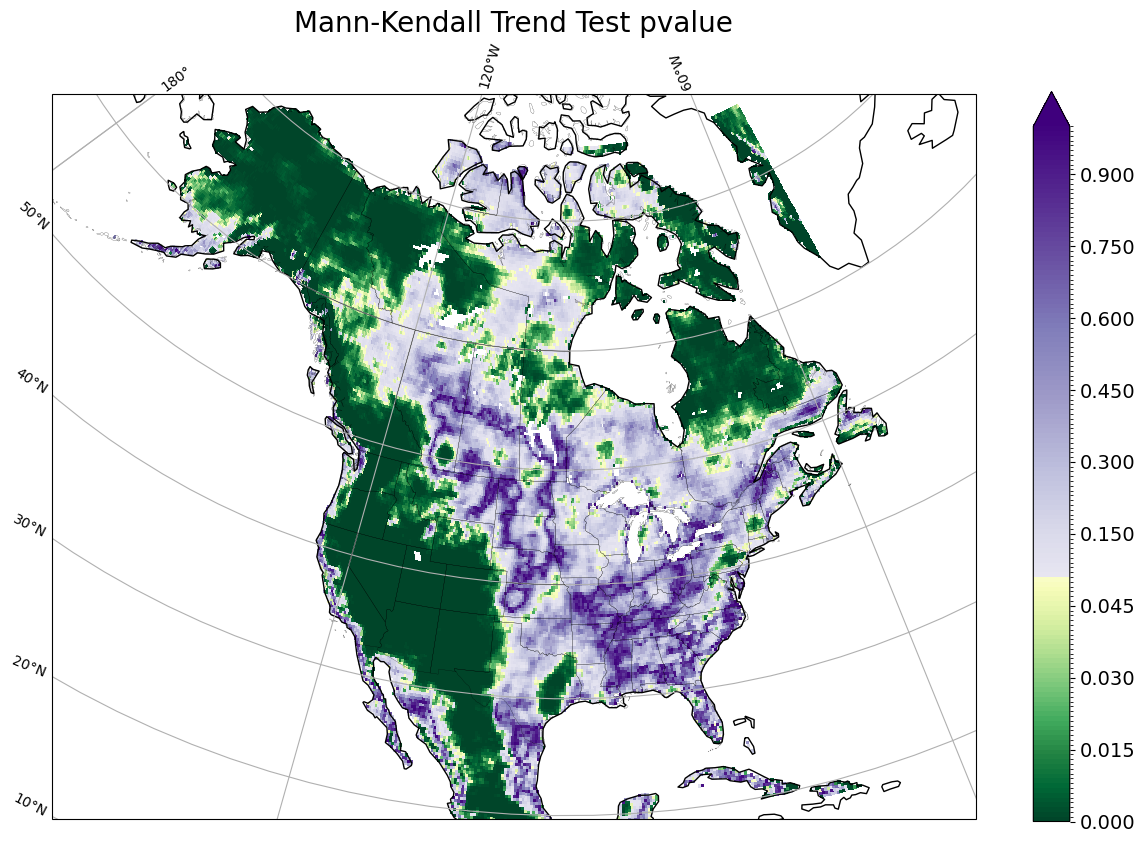

In [96]:
proj=ccrs.LambertConformal(265,25)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.95)

clevs = np.arange(0,3.25,0.25)
cc=mkp.plot.pcolormesh(ax=ax,cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(), add_colorbar=False)
ax.set_extent([-140+360, -60, 15, 75], ccrs.Geodetic())
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
cbar=fig.colorbar(cc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)  
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels
plt.title(f'Mann-Kendall Trend Test pvalue',fontsize=20)

The Mann-Kendall (MK) test detects monotonic upward or downward trends in time-series data without assuming normality. It uses a statistic, \(S\), where positive values indicate an increasing trend and negative values indicate a decreasing trend. Significance is determined by the p-value (often <0.05) and Kendall’s Tau (\(\tau \))

Text(0.5, 1.0, 'Mann-Kendall Trend Test Tau')

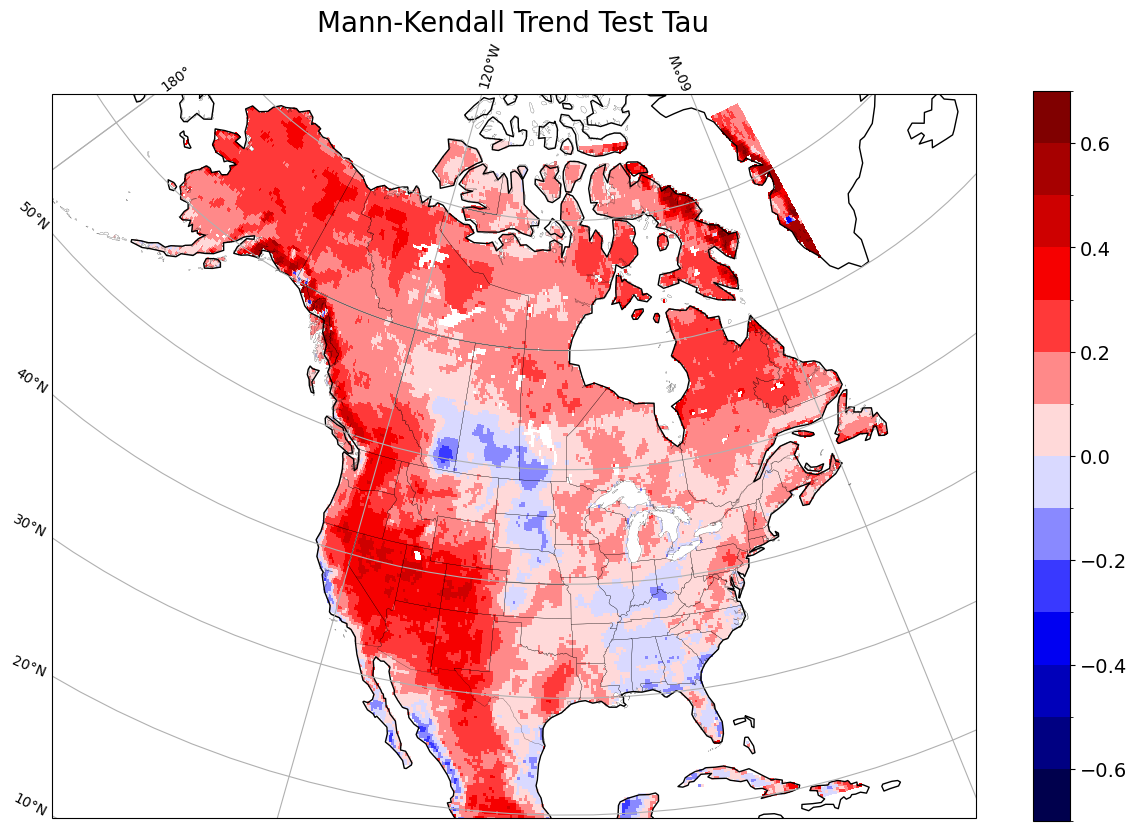

In [16]:
proj=ccrs.LambertConformal(265,25)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.95)

clevs = np.arange(0,3.25,0.25)
cc=mkt.plot.pcolormesh(ax=ax,cmap='seismic',levels=np.arange(-0.7,0.8,0.1),transform=ccrs.PlateCarree(), add_colorbar=False)
ax.set_extent([-140+360, -60, 15, 75], ccrs.Geodetic())
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
cbar=fig.colorbar(cc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)  
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels
plt.title(f'Mann-Kendall Trend Test Tau',fontsize=20)

In [ ]:
dse=xr.open_dataset('/TXx_CONUS_ij_glost_extremes_1941_2025.nc')
pvalue=dse['pvalue']

In [19]:
## Build colorbar
from matplotlib import cm
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
clevs_pv=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

Text(0.5, 0.98, 'p-value of Non Stationary hypothesis\n extRemes analysis covariante glost on Location + scale parameters')

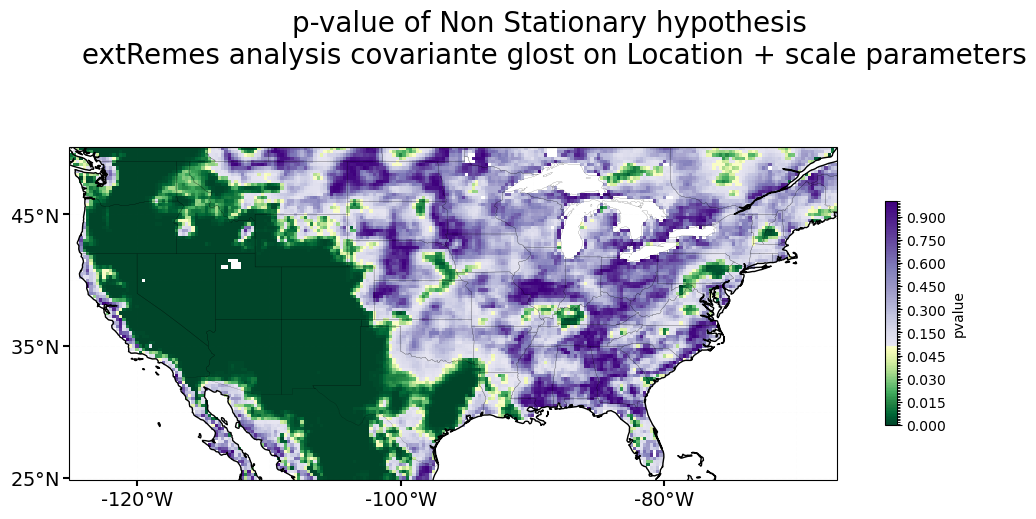

In [20]:
proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(12,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.16)
pvalue.plot.pcolormesh(ax=ax,cmap=pvalue_cmap,levels=clevs_pv,cbar_kwargs={'shrink':0.4})
#dw.sel(lon=dse.lon,lat=dse.lat).plot.contour(ax=ax,colors='k',levels=[1.5,2.5],transform=ccrs.PlateCarree())
#adf.sel(lon=dse.lon,lat=dse.lat).plot.contour(ax=ax,colors='m',levels=[0.05],transform=ccrs.PlateCarree())
grd = ax.gridlines(
draw_labels=False, 
color='gray', alpha=0.01, linestyle='--')
ax.set_title(f'',fontsize=18)  
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax.get_xticks()],size=14)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.1) 
ax.coastlines()

ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=14)
#
#
plt.suptitle(f'p-value of Non Stationary hypothesis\n extRemes analysis covariante glost on Location + scale parameters',fontsize=20)  